In [1]:
!pip install -q open_clip_torch
!pip install -q faiss-cpu
!pip install -q opencv-python pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 81.1 MB/s eta 0:00:00


In [2]:
import os
import cv2
import faiss
import torch
import open_clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

In [5]:
uploaded = files.upload()

Saving Clip_4 Working on laptop.mp4 to Clip_4 Working on laptop.mp4
Saving Clip_5 walking and hiking.mp4 to Clip_5 walking and hiking.mp4
Saving Clip_01 Natural Pink Beverage Guice.mp4 to Clip_01 Natural Pink Beverage Guice (1).mp4
Saving Clip_03 Girl Makaing Breakfast.mp4 to Clip_03 Girl Makaing Breakfast (1).mp4
Saving Clip_02 Tomato Garlic Rice.mp4 to Clip_02 Tomato Garlic Rice.mp4


In [6]:
import shutil

if os.path.exists("frames"):
    shutil.rmtree("frames")

os.makedirs("frames", exist_ok=True)

print("Frames folder created.")

Frames folder created.


In [7]:
frame_folder = "frames"

metadata = []

frame_interval = 10

saved = 0

video_files = [
    f for f in os.listdir()
    if f.endswith(".mp4")
]

for video in video_files:

    cap = cv2.VideoCapture(video)

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_no = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_no % frame_interval == 0:

            frame_name = f"{os.path.splitext(video)[0]}_{frame_no}.jpg"

            frame_path = os.path.join(frame_folder, frame_name)

            cv2.imwrite(frame_path, frame)

            metadata.append({
                "frame": frame_name,
                "video": video,
                "timestamp": frame_no / fps
            })

            saved += 1

        frame_no += 1

    cap.release()

print("Total Frames Saved:", saved)

Total Frames Saved: 499


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

model = model.to(device)

print("Device:", device)
print("✅ CLIP Model Loaded Successfully!")

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

Device: cpu
✅ CLIP Model Loaded Successfully!


In [24]:
frame_folder = "frames"

metadata = []

frame_interval = 10

saved = 0

video_files = [
    f for f in os.listdir()
    if f.endswith(".mp4")
]

for video in video_files:

    cap = cv2.VideoCapture(video)

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_no = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_no % frame_interval == 0:

            frame_name = f"{os.path.splitext(video)[0]}_{frame_no}.jpg"

            frame_path = os.path.join(frame_folder, frame_name)

            cv2.imwrite(frame_path, frame)

            metadata.append({
                "frame": frame_name,
                "video": os.path.splitext(video)[0],
                "frame_number": frame_no,
                "timestamp": frame_no / fps
            })

            saved += 1

        frame_no += 1

    cap.release()

print("✅ Total Frames Saved:", saved)

✅ Total Frames Saved: 499


In [25]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("FAISS Index Created Successfully!")
print("Total Indexed Frames:", index.ntotal)

FAISS Index Created Successfully!
Total Indexed Frames: 499


In [27]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():

    text_embedding = model.encode_text(text)

    text_embedding /= text_embedding.norm(dim=-1, keepdim=True)

text_embedding = text_embedding.cpu().numpy().astype("float32")

D, I = index.search(text_embedding, 5)

Enter your search query: cooking


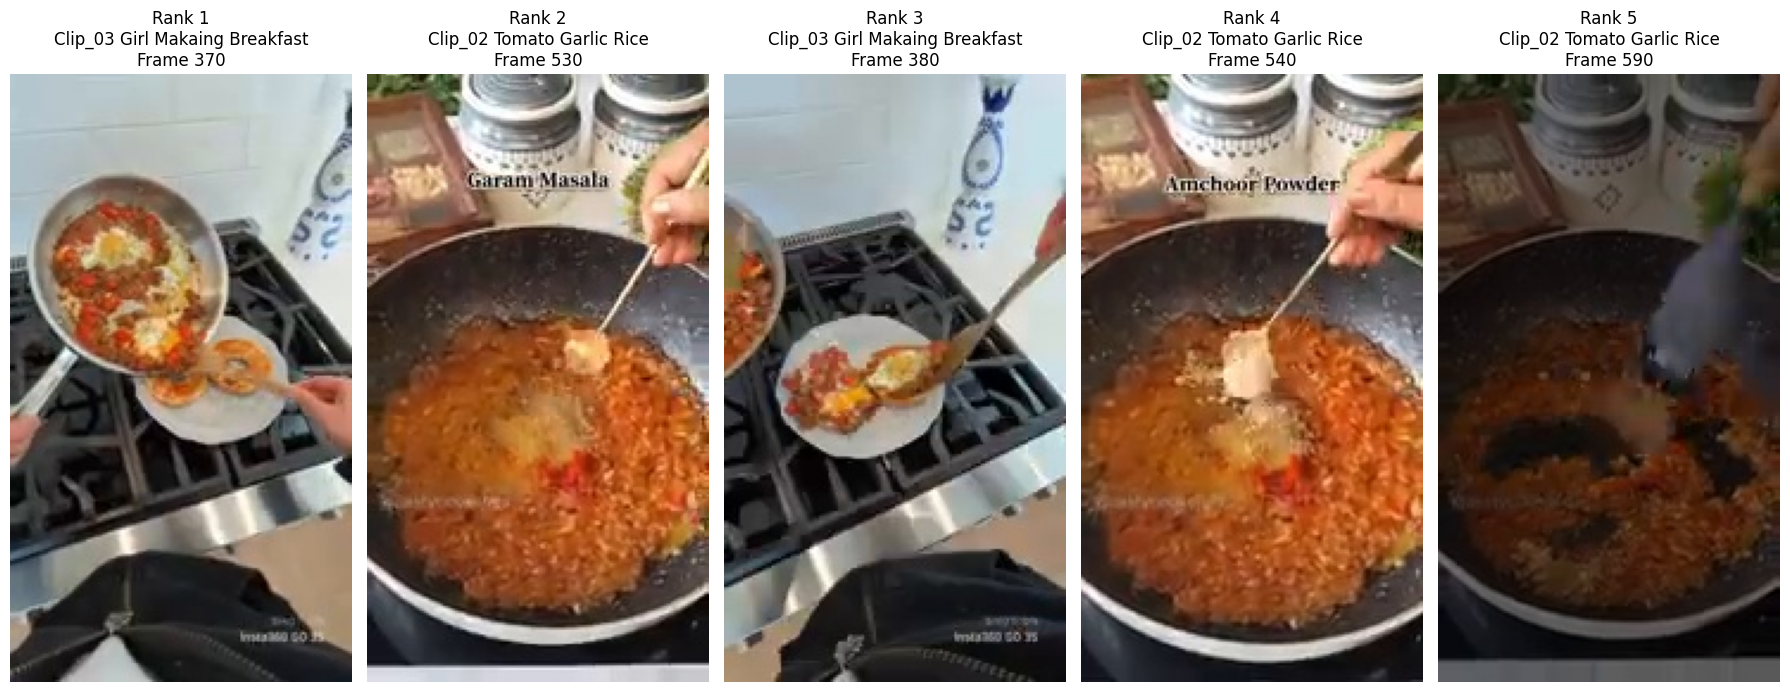

In [28]:
plt.figure(figsize=(18,8))

for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    image = Image.open(os.path.join("frames", info["frame"]))

    plt.subplot(1,5,rank+1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Rank {rank+1}\n{info['video']}\nFrame {info['frame_number']}"
    )

plt.tight_layout()
plt.show()

In [29]:
fps = 30   # change this if your videos have a different FPS

print("\nTop Matches\n")

for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    timestamp = info["frame_number"] / fps

    print(f"Rank {rank+1}")
    print("Video :", info["video"])
    print("Timestamp :", round(timestamp,2), "seconds")
    print("-"*40)


Top Matches

Rank 1
Video : Clip_03 Girl Makaing Breakfast
Timestamp : 12.33 seconds
----------------------------------------
Rank 2
Video : Clip_02 Tomato Garlic Rice
Timestamp : 17.67 seconds
----------------------------------------
Rank 3
Video : Clip_03 Girl Makaing Breakfast
Timestamp : 12.67 seconds
----------------------------------------
Rank 4
Video : Clip_02 Tomato Garlic Rice
Timestamp : 18.0 seconds
----------------------------------------
Rank 5
Video : Clip_02 Tomato Garlic Rice
Timestamp : 19.67 seconds
----------------------------------------


In [43]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():

    text_embedding = model.encode_text(text)

    text_embedding /= text_embedding.norm(dim=-1, keepdim=True)

text_embedding = text_embedding.cpu().numpy().astype("float32")

D, I = index.search(text_embedding, 5)

Enter your search query: person


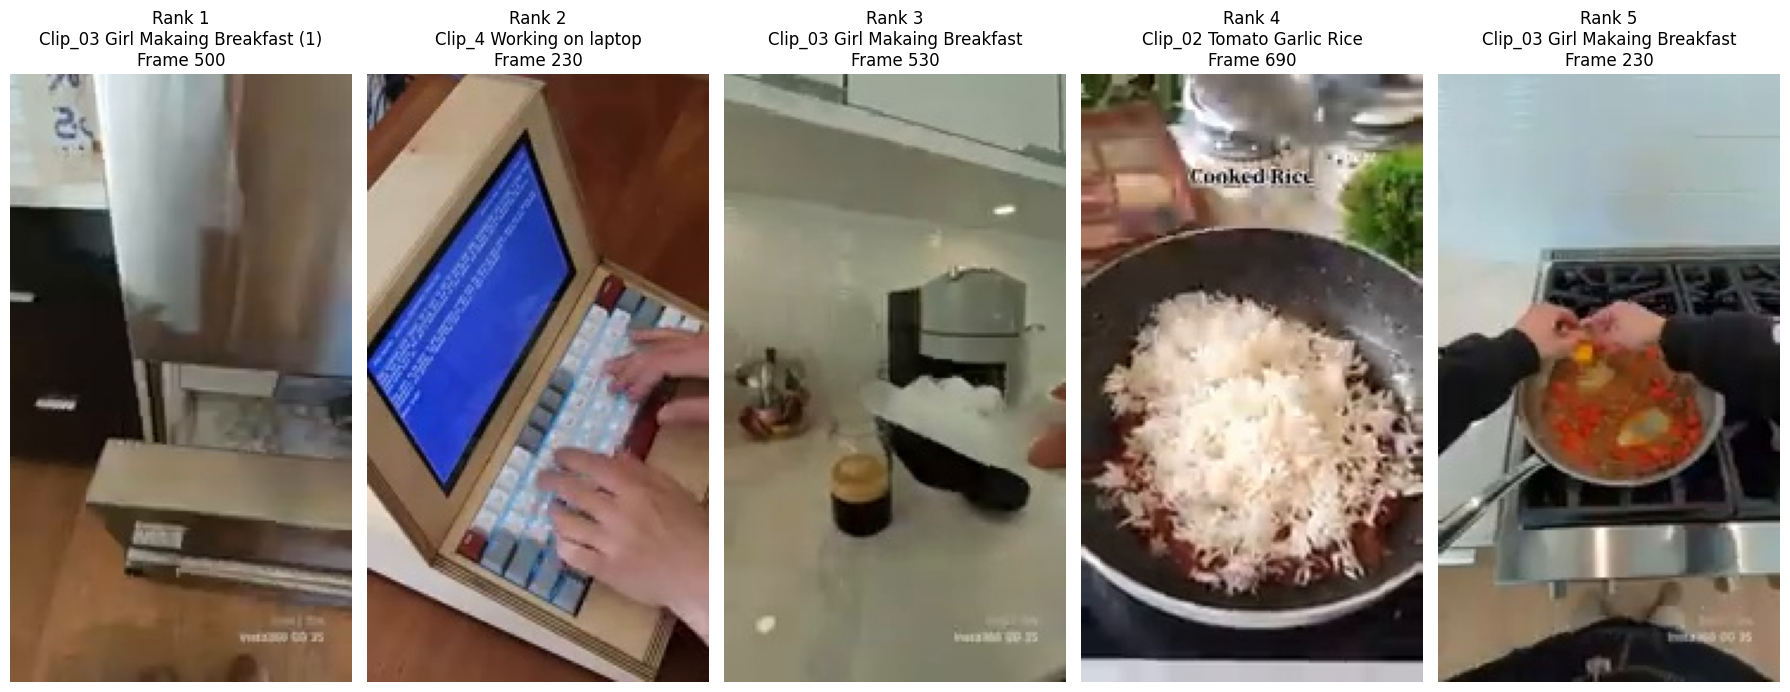

In [44]:
plt.figure(figsize=(18,8))

for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    image = Image.open(os.path.join("frames", info["frame"]))

    plt.subplot(1,5,rank+1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Rank {rank+1}\n{info['video']}\nFrame {info['frame_number']}"
    )

plt.tight_layout()
plt.show()

In [51]:
fps = 30   # change this if your videos have a different FPS

print("\nTop Matches\n")

for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    timestamp = info["frame_number"] / fps

    print(f"Rank {rank+1}")
    print("Video :", info["video"])
    print("Timestamp :", round(timestamp,2), "seconds")
    print("-"*40)


Top Matches

Rank 1
Video : Clip_03 Girl Makaing Breakfast (1)
Timestamp : 19.0 seconds
----------------------------------------
Rank 2
Video : Clip_4 Working on laptop
Timestamp : 10.0 seconds
----------------------------------------
Rank 3
Video : Clip_01 Natural Pink Beverage Guice (1)
Timestamp : 7.0 seconds
----------------------------------------
Rank 4
Video : Clip_03 Girl Makaing Breakfast (1)
Timestamp : 7.33 seconds
----------------------------------------
Rank 5
Video : Clip_03 Girl Makaing Breakfast (1)
Timestamp : 18.67 seconds
----------------------------------------


In [52]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():

    text_embedding = model.encode_text(text)

    text_embedding /= text_embedding.norm(dim=-1, keepdim=True)

text_embedding = text_embedding.cpu().numpy().astype("float32")

D, I = index.search(text_embedding, 5)

Enter your search query: forest


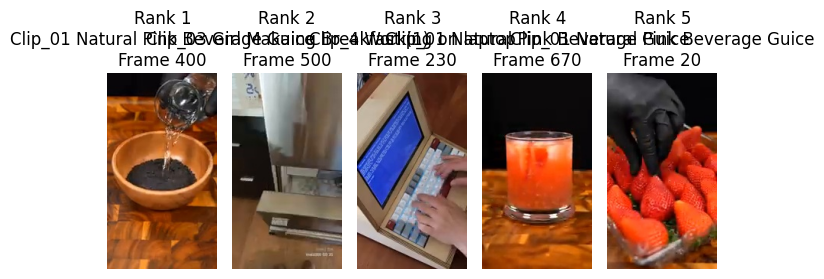

In [53]:
for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    image = Image.open(os.path.join("frames", info["frame"]))

    plt.subplot(1,5,rank+1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Rank {rank+1}\n{info['video']}\nFrame {info['frame_number']}"
    )

plt.tight_layout()
plt.show()

In [54]:
fps = 30   # change this if your videos have a different FPS

print("\nTop Matches\n")

for rank, idx in enumerate(I[0]):

    info = metadata[idx]

    timestamp = info["frame_number"] / fps

    print(f"Rank {rank+1}")
    print("Video :", info["video"])
    print("Timestamp :", round(timestamp,2), "seconds")
    print("-"*40)


Top Matches

Rank 1
Video : Clip_01 Natural Pink Beverage Guice
Timestamp : 13.33 seconds
----------------------------------------
Rank 2
Video : Clip_03 Girl Makaing Breakfast (1)
Timestamp : 16.67 seconds
----------------------------------------
Rank 3
Video : Clip_4 Working on laptop
Timestamp : 7.67 seconds
----------------------------------------
Rank 4
Video : Clip_01 Natural Pink Beverage Guice
Timestamp : 22.33 seconds
----------------------------------------
Rank 5
Video : Clip_01 Natural Pink Beverage Guice
Timestamp : 0.67 seconds
----------------------------------------


In [55]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)

index.add(embeddings)

print("Total Indexed Frames:", index.ntotal)

Total Indexed Frames: 499


In [56]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text)

text_features /= text_features.norm(dim=-1, keepdim=True)

text_embedding = text_features.cpu().numpy().astype("float32")

faiss.normalize_L2(text_embedding)

D, I = index.search(text_embedding, 5)

Enter your search query: Laptop


Rank: 1
Video: Clip_5 walking and hiking
Timestamp: 13.67 seconds


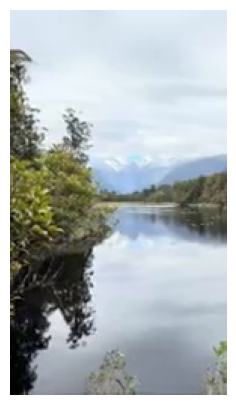

Rank: 2
Video: Clip_5 walking and hiking
Timestamp: 11.67 seconds


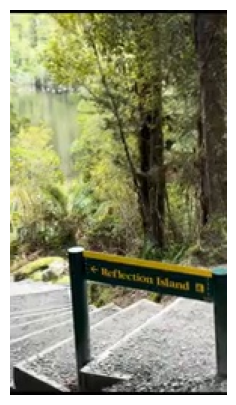

Rank: 3
Video: Clip_5 walking and hiking
Timestamp: 11.33 seconds


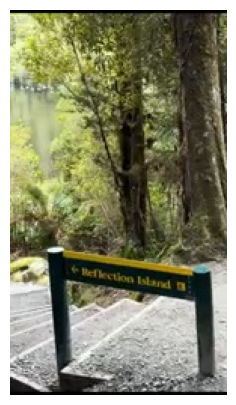

Rank: 4
Video: Clip_5 walking and hiking
Timestamp: 13.33 seconds


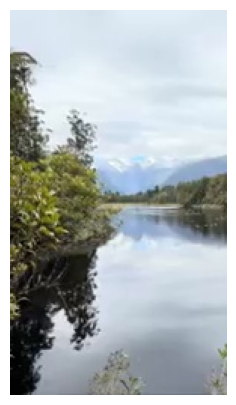

Rank: 5
Video: Clip_5 walking and hiking
Timestamp: 12.33 seconds


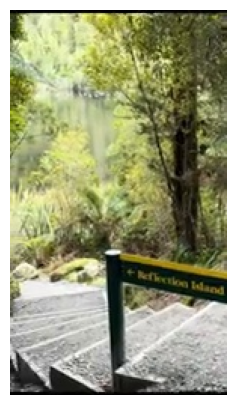

In [57]:
for rank, idx in enumerate(I[0]):

    item = metadata[idx]

    print("=" * 60)
    print(f"Rank: {rank+1}")
    print("Video:", item["video"])
    print("Timestamp:", round(item["timestamp"],2), "seconds")

    img = Image.open(os.path.join("frames", item["frame"]))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [58]:
metadata[0]

{'frame': 'Clip_4 Working on laptop_0.jpg',
 'video': 'Clip_4 Working on laptop',
 'frame_number': 0,
 'timestamp': 0.0}

In [59]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)

index.add(embeddings)

print("Total Indexed Frames:", index.ntotal)

Total Indexed Frames: 499


In [60]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text)

text_features /= text_features.norm(dim=-1, keepdim=True)

text_embedding = text_features.cpu().numpy().astype("float32")

faiss.normalize_L2(text_embedding)

D, I = index.search(text_embedding, 5)

Enter your search query: Cooking


Rank: 1
Video: Clip_03 Girl Makaing Breakfast
Timestamp: 12.33 seconds


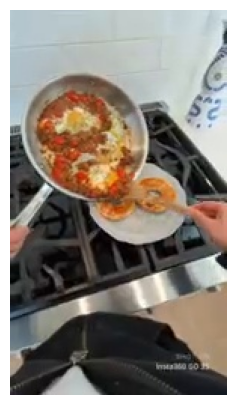

Rank: 2
Video: Clip_02 Tomato Garlic Rice
Timestamp: 17.67 seconds


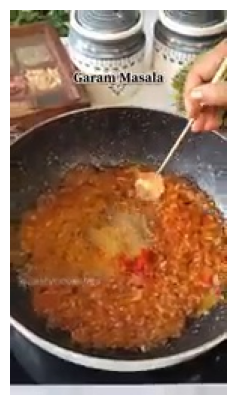

Rank: 3
Video: Clip_03 Girl Makaing Breakfast
Timestamp: 12.67 seconds


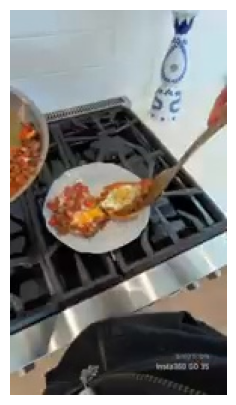

Rank: 4
Video: Clip_02 Tomato Garlic Rice
Timestamp: 18.0 seconds


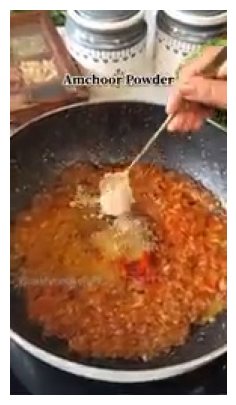

Rank: 5
Video: Clip_02 Tomato Garlic Rice
Timestamp: 19.67 seconds


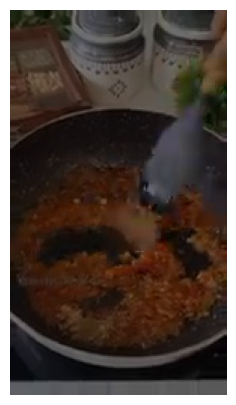

In [61]:
for rank, idx in enumerate(I[0]):

    item = metadata[idx]

    print("=" * 60)
    print(f"Rank: {rank+1}")
    print("Video:", item["video"])
    print("Timestamp:", round(item["timestamp"],2), "seconds")

    img = Image.open(os.path.join("frames", item["frame"]))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [62]:
query = input("Enter your search query: ")

text = tokenizer([query]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text)

text_features /= text_features.norm(dim=-1, keepdim=True)

text_embedding = text_features.cpu().numpy().astype("float32")

faiss.normalize_L2(text_embedding)

D, I = index.search(text_embedding, 5)

Enter your search query: Forest


Rank: 1
Video: Clip_01 Natural Pink Beverage Guice
Timestamp: 13.33 seconds


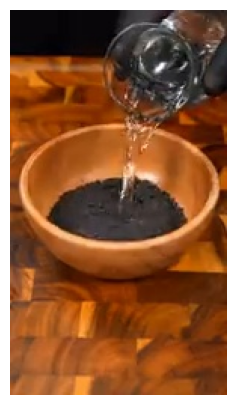

Rank: 2
Video: Clip_03 Girl Makaing Breakfast (1)
Timestamp: 16.67 seconds


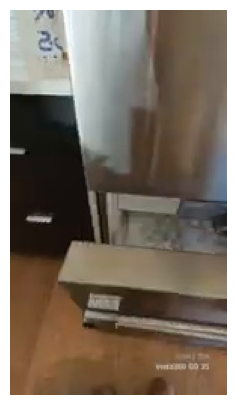

Rank: 3
Video: Clip_4 Working on laptop
Timestamp: 9.59 seconds


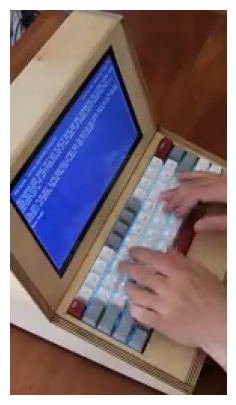

Rank: 4
Video: Clip_01 Natural Pink Beverage Guice
Timestamp: 22.33 seconds


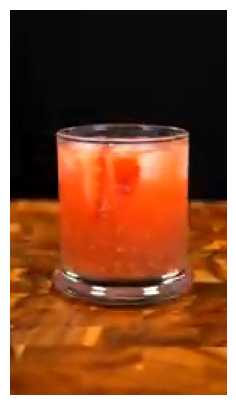

Rank: 5
Video: Clip_01 Natural Pink Beverage Guice
Timestamp: 0.67 seconds


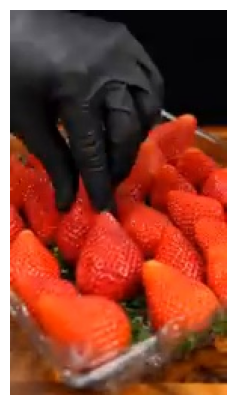

In [63]:
for rank, idx in enumerate(I[0]):

    item = metadata[idx]

    print("=" * 60)
    print(f"Rank: {rank+1}")
    print("Video:", item["video"])
    print("Timestamp:", round(item["timestamp"],2), "seconds")

    img = Image.open(os.path.join("frames", item["frame"]))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [64]:
print("Metadata:", len(metadata))
print("Embeddings:", embeddings.shape)
print("Index:", index.ntotal)

Metadata: 499
Embeddings: (499, 512)
Index: 499
